In [1]:
# PDF 파일들 
pdf_attention = "data/Attention Is All You Need.pdf"
pdf_bert = "data/BERT.pdf"
pdf_lg_aimers = "data/LG Aimers 4기 소개자료.pdf"

In [2]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader(pdf_lg_aimers)

In [3]:
docs = loader.load()
print(f"PDF 파일의 페이지 수: {len(docs)}")

PDF 파일의 페이지 수: 7


In [4]:
docs[1].metadata

{'source': 'data/LG Aimers 4기 소개자료.pdf',
 'file_path': 'data/LG Aimers 4기 소개자료.pdf',
 'page': 1,
 'total_pages': 7,
 'CreationDate': "D:20250715074032+00'00'",
 'ModDate': "D:20250715074032+00'00'"}

In [5]:
print(docs[1].page_content[:300])

1. LG Aimers 프로그램 개요
❑교육과 경험의 기회를 필요로 하는 청년들에게 양질의 AI교육을 온라인으로 제공하고, 기업의 실제 data를 다루며
실무를 경험할 수 있는 기회를 제공하기 위해 『온라인 AI전문가 과정(1개월)』 과 『AI 해커톤 (Hackathon)(1개월)』을
결합한 형태의 교육 프로그램
- 온라인 AI 교육 과정 : 국내 AI 전문가 (현업 전문가, 저명 교수)의 최신 AI 기법에 관한 온라인 강의(1개월)
• 온라인 초급 교육은 기초적인 프로그래밍데이터 처리에 관련된 내용들로써 외부 교육 콘텐츠를 활용(


In [6]:
import pdfplumber

with pdfplumber.open(pdf_bert) as pdf:
    metadata = pdf.metadata
    print(metadata)

{'Author': '', 'CreationDate': 'D:20190528000751Z', 'Creator': 'LaTeX with hyperref package', 'Keywords': '', 'ModDate': 'D:20190528000751Z', 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2', 'Producer': 'pdfTeX-1.40.17', 'Subject': '', 'Title': '', 'Trapped': 'False'}


In [7]:
with pdfplumber.open(pdf_bert) as pdf:
    text = pdf.pages[0].extract_text()
    print(text[:300])

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 


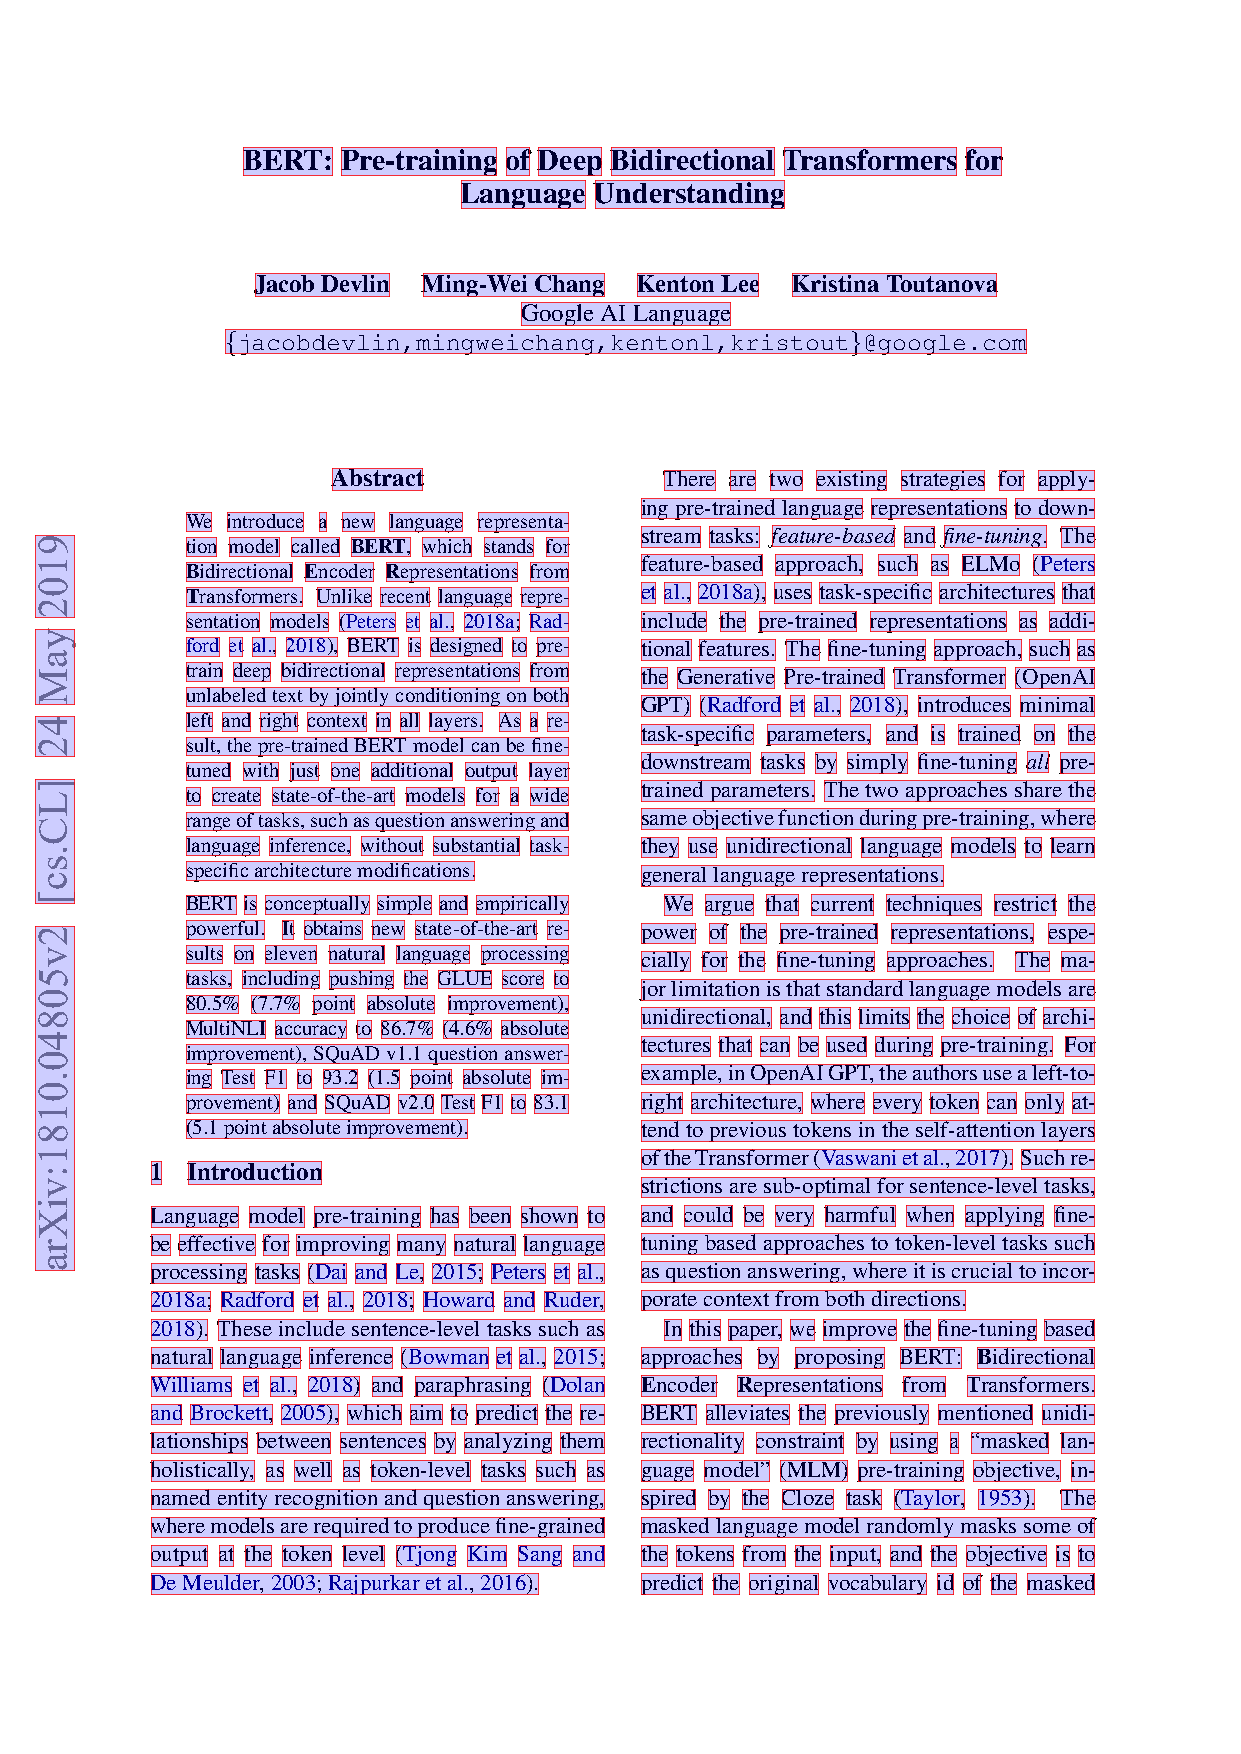

In [8]:
with pdfplumber.open(pdf_bert) as pdf:
    pages = pdf.pages
    im = pages[0].to_image(resolution=150)
    im.draw_rects(pages[0].extract_words())

im

In [9]:
import pdfplumber
from langchain_core.documents import Document

# Open the PDF file"
documents = []

with pdfplumber.open(pdf_bert) as pdf:
    dict_metadata = pdf.metadata

    # Iterate through all the pages in the PDF document
    for i, page in enumerate(pdf.pages):
        # Extract and print the text content of each page
        dict_metadata['page_no'] = i+1
        documents.append(Document(
            page_content=page.extract_text(),
            metadata=dict_metadata
        ))

In [10]:
documents[0].metadata # 추출된 메타데이터 확인 

{'Author': '',
 'CreationDate': 'D:20190528000751Z',
 'Creator': 'LaTeX with hyperref package',
 'Keywords': '',
 'ModDate': 'D:20190528000751Z',
 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2',
 'Producer': 'pdfTeX-1.40.17',
 'Subject': '',
 'Title': '',
 'Trapped': 'False',
 'page_no': 1}

In [11]:
print(documents[0].page_content[:300]) # 추출된 텍스트 확인 

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 
